# Tutorial 01 — Population inference on a small cluster sample, four ways

**The core idea of the paper in one notebook.** We take **N = 25** simulated cluster weak-lensing
observations and infer the *population* mass–concentration distribution with three methods:

| color | method | per-cluster step | population step |
|---|---|---|---|
| 🟩 green | **Hierarchical HMC** *(paper)* | sampled jointly (latents) | NUTS on hyperparameters (differentiable model) |
| 🟨 amber | **HMC + recycling** *(validation variant, not in the paper)* | per-cluster NUTS (flat prior), cached | reweight cached samples (importance sampling) |
| 🟦 blue | **Hybrid SBI-HMC** *(paper)* | amortized SBI (NPE) posteriors, cached | HMC on hyperparameters over the cached samples |
| 🟧 vermillion | **Hierarchical SBI** *(paper)* | — (end-to-end) | neural posterior trained to map all profiles → hyperparameters |

The colors match the paper's comparison figures. All methods answer the same question with the same priors — the punchline is that they **agree**.

*Runtime:* first fresh run ≈ 10–20 min (SBI training dominates); everything is cached in `cache/`,
so re-runs take seconds. Delete `cache/` to recompute from scratch. The 5 observations live in
`data/` (committed, fixed seed) so everyone runs on identical inputs.

In [1]:
# --- setup: imports, paths, cache helper -------------------------------------
import os, sys, time, pickle, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt

# repo root = two levels up from this notebook
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
assert os.path.isdir(os.path.join(ROOT, "weaklensclustersbi")), f"repo root not found from {os.getcwd()}"
sys.path.insert(0, ROOT)

DATA, CACHE = "data", "cache"
os.makedirs(DATA, exist_ok=True); os.makedirs(CACHE, exist_ok=True)
TIMINGS = {}

def cached(name, fn, where=CACHE):
    """Load `where`/name.pkl if present, else compute fn(), save, and record timing."""
    path = os.path.join(where, f"{name}.pkl")
    if os.path.isfile(path):
        TIMINGS[name] = ("cached", None)
        with open(path, "rb") as f: return pickle.load(f)
    t0 = time.perf_counter(); val = fn(); dt = time.perf_counter() - t0
    TIMINGS[name] = ("computed", dt)
    with open(path, "wb") as f: pickle.dump(val, f)
    print(f"[{name}] computed in {dt:.1f}s (cached for next run)")
    return val

# package machinery (imported, not re-implemented -- see the paper / repo)
from weaklensclustersbi.simulations import population, wlprofile

def kde_contours(ax, samples, color, levels=(0.68, 0.95), ls="-", lw=1.8, fill=False, alpha=0.18):
    """2D KDE contours enclosing the given probability mass."""
    from scipy import stats as _st
    x, y = samples[:, 0], samples[:, 1]
    xx, yy = np.mgrid[x.min():x.max():90j, y.min():y.max():90j]
    f = np.reshape(_st.gaussian_kde(samples.T)(np.vstack([xx.ravel(), yy.ravel()])), xx.shape)
    sf = np.sort(f.ravel())[::-1]; cs = np.cumsum(sf); cs /= cs[-1]
    cl = sorted(sf[np.searchsorted(cs, lv)] for lv in levels)
    if fill: ax.contourf(xx, yy, f, levels=[cl[0], f.max()], colors=[color], alpha=alpha)
    ax.contour(xx, yy, f, levels=cl, colors=[color], linewidths=lw, linestyles=ls)

N_CLUSTERS = 25         # scale freely -- all caches are keyed by N
NOISE_DEX  = 0.3        # per-radial-bin log-normal noise (paper baseline)
Z          = 0.275      # mid of the 0.2 < z < 0.35 bin
RBINS      = 10 ** np.arange(0, 3, 0.1)   # 30 log-spaced radii [kpc/h]
SEED       = 11

## 1. The data: N clusters from one richness bin

We draw `N_CLUSTERS` clusters from the paper's baseline population — the $30<\lambda<45$ richness bin
(McClintock+18 richness–mass relation, Child+18 concentration–mass relation, Tinker08 mass
function weighting) — and observe each as a noisy **excess surface density** $\Delta\Sigma(R)$
profile (0.3 dex log-normal noise per radial bin), exactly as in the paper.

The five clusters (truth):
  cluster 0:  log10 M = 14.452   c = 4.714
  cluster 1:  log10 M = 14.480   c = 4.549
  cluster 2:  log10 M = 14.514   c = 4.243
  cluster 3:  log10 M = 14.240   c = 4.683
  cluster 4:  log10 M = 14.300   c = 4.543
  cluster 5:  log10 M = 14.380   c = 4.580
  cluster 6:  log10 M = 14.219   c = 4.733
  cluster 7:  log10 M = 14.191   c = 5.033
  cluster 8:  log10 M = 14.441   c = 4.629
  cluster 9:  log10 M = 14.732   c = 4.267
  cluster 10:  log10 M = 14.267   c = 4.548
  cluster 11:  log10 M = 14.320   c = 4.991
  cluster 12:  log10 M = 14.280   c = 4.635
  cluster 13:  log10 M = 14.355   c = 4.593
  cluster 14:  log10 M = 14.395   c = 4.776
  cluster 15:  log10 M = 14.286   c = 4.793
  cluster 16:  log10 M = 14.427   c = 4.660
  cluster 17:  log10 M = 14.390   c = 4.591
  cluster 18:  log10 M = 14.310   c = 4.617
  cluster 19:  log10 M = 14.348   c = 4.547
  cluster 20:  log10 M = 14.329   c = 4.602
  cluster 21:  log10 M = 14.459   c = 4.364
  cluster 22:  

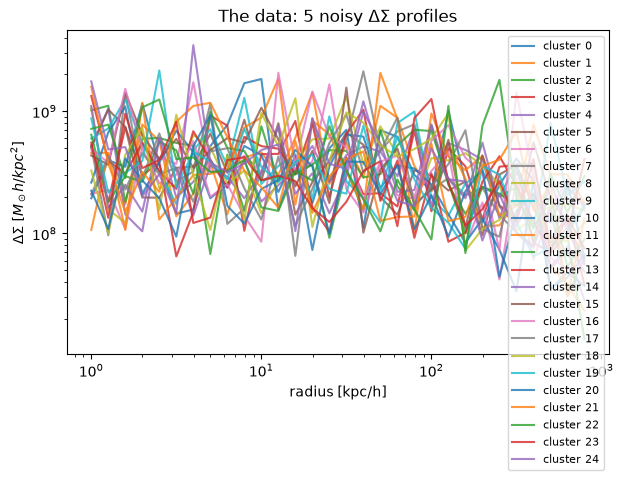

In [2]:
def make_observations():
    np.random.seed(SEED)
    for _ in range(5):  # retry: the richness-bin sampler very occasionally hiccups
        try:
            pairs = np.asarray(population.gen_mc_pairs_in_richness_bin(
                30, 45, rm_relation="mcclintock18", mc_relation="child18",
                num_samples=N_CLUSTERS, mc_scatter=0.1, rm_scatter=0.1,
                min_z=0.2, max_z=0.35))
            break
        except TypeError:
            continue
    profs = np.array([wlprofile.simulate_nfw(m, c, RBINS, Z, kind="delta_sigma") for m, c in pairs])
    noisy = np.log10(population.calculate_noise(profs, NOISE_DEX))
    return {"true_mc": pairs, "log_profiles": noisy}

def make_truth_population():
    np.random.seed(4242)
    pop = np.asarray(population.gen_mc_pairs_in_richness_bin(
        30, 45, rm_relation="mcclintock18", mc_relation="child18",
        num_samples=20000, mc_scatter=0.1, rm_scatter=0.1, min_z=0.2, max_z=0.35))
    return pop

OBS  = cached(f"observations_N{N_CLUSTERS}", make_observations, where=DATA)
POP  = cached("truth_population", make_truth_population, where=DATA)
TRUE = dict(mu_M=POP[:,0].mean(), sig_M=POP[:,0].std(), mu_c=POP[:,1].mean(), sig_c=POP[:,1].std())

print("The five clusters (truth):")
for i, (m, c) in enumerate(OBS["true_mc"]):
    print(f"  cluster {i}:  log10 M = {m:.3f}   c = {c:.3f}")
print(f"TRUE population:  mu_M={TRUE['mu_M']:.3f}  sig_M={TRUE['sig_M']:.3f}  mu_c={TRUE['mu_c']:.3f}  sig_c={TRUE['sig_c']:.3f}")

fig, ax = plt.subplots(figsize=(7, 4.2))
for i in range(N_CLUSTERS):
    ax.plot(RBINS, 10 ** OBS["log_profiles"][i], alpha=0.8, label=f"cluster {i}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("radius [kpc/h]"); ax.set_ylabel(r"$\Delta\Sigma$ [$M_\odot h/kpc^2$]")
ax.set_title("The data: 5 noisy $\\Delta\\Sigma$ profiles"); ax.legend(fontsize=8); plt.show()

## 2. The per-cluster problem

One noisy profile constrains $(\log_{10}M, c)$ only weakly, with a strong mass–concentration
degeneracy. We train a small **amortized SBI posterior** (NPE, flat prior over a wide box) once —
it then evaluates the posterior for *any* cluster in milliseconds. (This same network is reused by
the 🟤 hybrid method below.)

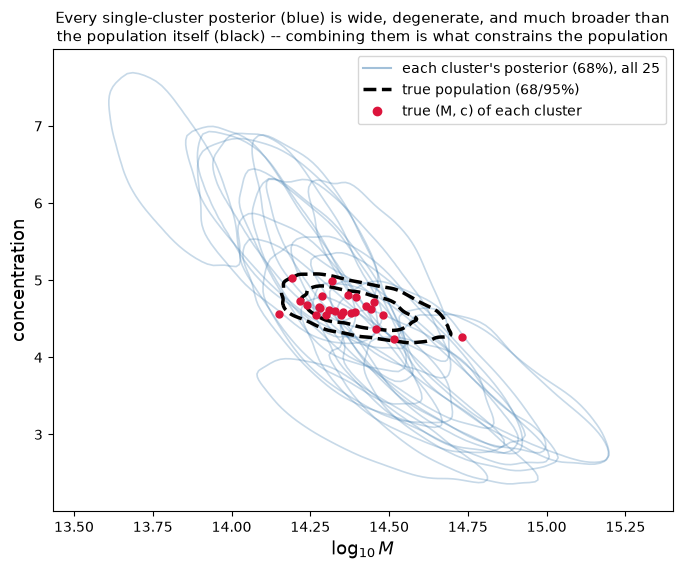

In [3]:
import torch
from sbi.inference import SNPE
from sbi.utils import BoxUniform

BOX_LO, BOX_HI = [13.4, 2.0], [15.4, 8.0]      # flat NPE prior (simplifies recycling: it cancels)

def train_percluster_npe(n_train=4000):
    torch.manual_seed(SEED); np.random.seed(SEED)
    prior = BoxUniform(low=torch.tensor(BOX_LO), high=torch.tensor(BOX_HI))
    theta = prior.sample((n_train,)).numpy()
    x = np.array([np.log10(population.calculate_noise(
            wlprofile.simulate_nfw(m, c, RBINS, Z, kind="delta_sigma"), NOISE_DEX))
        for m, c in theta])
    inf = SNPE(prior=prior, density_estimator="maf")
    de = inf.append_simulations(torch.as_tensor(theta, dtype=torch.float32),
                                torch.as_tensor(x, dtype=torch.float32)).train(show_train_summary=False)
    return inf.build_posterior(de)

npe = cached("percluster_npe", train_percluster_npe)

def percluster_samples(n=2000):
    out = []
    for i in range(N_CLUSTERS):
        s = npe.sample((n,), x=torch.as_tensor(OBS["log_profiles"][i], dtype=torch.float32),
                       show_progress_bars=False).numpy()
        out.append(s)
    return np.array(out)                        # (N_CLUSTERS, n, 2)

PC = cached(f"percluster_samples_N{N_CLUSTERS}", percluster_samples)
np.savez(os.path.join(DATA, f"percluster_posteriors_N{N_CLUSTERS}.npz"), samples=PC, true_mc=OBS["true_mc"])  # shared deliverable

fig, ax = plt.subplots(figsize=(8, 6))
from matplotlib.colors import to_rgba
for j in range(N_CLUSTERS):                                   # every cluster's 68% contour, ghosted
    kde_contours(ax, PC[j], to_rgba("steelblue", 0.30), levels=(0.68,), lw=1.2)
kde_contours(ax, POP[:8000], "k", ls="--", lw=2.5)            # true population (68/95%)
ax.scatter(OBS["true_mc"][:, 0], OBS["true_mc"][:, 1], s=25, color="crimson", zorder=5)
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], color="steelblue", alpha=0.5, lw=1.5,
                          label=f"each cluster's posterior (68%), all {N_CLUSTERS}"),
                   Line2D([], [], color="k", ls="--", lw=2.5, label="true population (68/95%)"),
                   Line2D([], [], marker="o", ls="", color="crimson", label="true (M, c) of each cluster")],
          fontsize=10, loc="upper right")
ax.set_xlabel(r"$\log_{10} M$", fontsize=13); ax.set_ylabel("concentration", fontsize=13)
ax.set_title("Every single-cluster posterior (blue) is wide, degenerate, and much broader than\n"
             "the population itself (black) -- combining them is what constrains the population", fontsize=11)
plt.show()

## 3. The population question

We model the population as independent Gaussians,
$\log_{10}M \sim \mathcal{N}(\mu_M, \sigma_M)$ and $c \sim \mathcal{N}(\mu_c, \sigma_c)$,
and infer the four **hyperparameters** $(\mu_M, \sigma_M, \mu_c, \sigma_c)$.
All three methods use the **same hyperprior**:
$\mu_M \sim \mathcal{N}(14.4, 0.3)$, $\sigma_M \sim \mathrm{HalfNormal}(0.25)$,
$\mu_c \sim \mathcal{N}(4.6, 0.8)$, $\sigma_c \sim \mathrm{HalfNormal}(0.5)$.

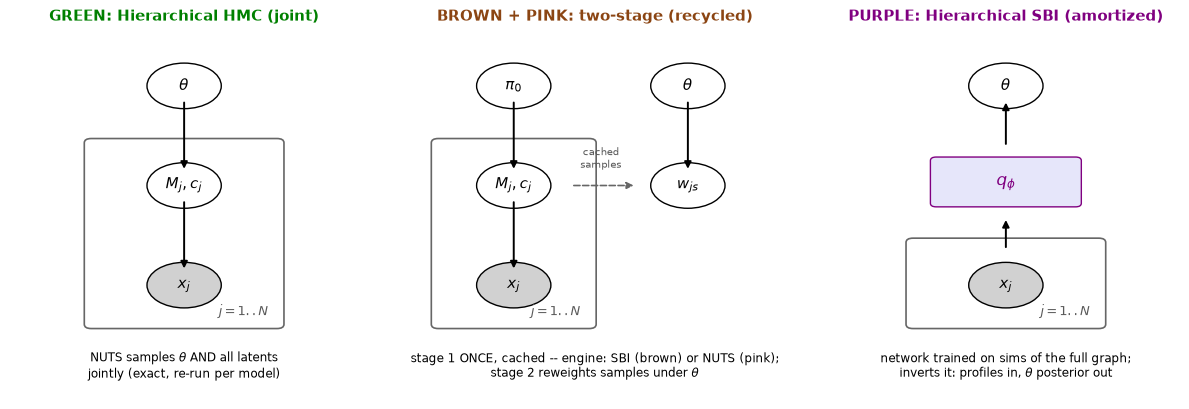

In [4]:
# --- what actually differs between the three approaches? (PGMs) ---------------
import matplotlib.patches as mpatches

def node(ax, x, y, label, observed=False, fs=11):
    ax.add_patch(plt.Circle((x, y), 0.32, fc="0.82" if observed else "white", ec="k", zorder=3))
    ax.text(x, y, label, ha="center", va="center", fontsize=fs, zorder=4)

def arrow(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color="k", lw=1.4, shrinkA=12, shrinkB=12))

def plate(ax, x, y, w, h, label):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.06",
                                         fill=False, ec="0.4", lw=1.2))
    ax.text(x + w - 0.08, y + 0.08, label, ha="right", va="bottom", fontsize=9, color="0.35")

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
for ax, title, color in zip(axes, ["GREEN: Hierarchical HMC (joint)", "BROWN + PINK: two-stage (recycled)",
                                   "PURPLE: Hierarchical SBI (amortized)"], ["green", "saddlebrown", "purple"]):
    ax.set_xlim(0, 3); ax.set_ylim(-0.9, 4.3); ax.axis("off")
    ax.set_title(title, fontsize=11, color=color, fontweight="bold")

# green: theta -> (M_j,c_j) -> x_j, one joint inference
ax = axes[0]
node(ax, 1.5, 3.5, r"$\theta$"); node(ax, 1.5, 2.1, r"$M_j, c_j$"); node(ax, 1.5, 0.7, r"$x_j$", observed=True)
arrow(ax, 1.5, 3.5, 1.5, 2.1); arrow(ax, 1.5, 2.1, 1.5, 0.7)
plate(ax, 0.7, 0.15, 1.6, 2.55, r"$j=1..N$")
ax.text(1.5, -0.6, "NUTS samples $\\theta$ AND all latents\njointly (exact, re-run per model)", ha="center", fontsize=8.5)

# brown: stage 1 per cluster with flat prior; stage 2 reweight cached samples by theta
ax = axes[1]
node(ax, 0.8, 3.5, r"$\pi_0$"); node(ax, 0.8, 2.1, r"$M_j, c_j$"); node(ax, 0.8, 0.7, r"$x_j$", observed=True)
arrow(ax, 0.8, 3.5, 0.8, 2.1); arrow(ax, 0.8, 2.1, 0.8, 0.7)
plate(ax, 0.15, 0.15, 1.3, 2.55, r"$j=1..N$")
node(ax, 2.3, 3.5, r"$\theta$"); node(ax, 2.3, 2.1, r"$w_{js}$")
arrow(ax, 2.3, 3.5, 2.3, 2.1)
ax.annotate("", xy=(2.0, 2.1), xytext=(1.15, 2.1),
            arrowprops=dict(arrowstyle="-|>", color="0.4", lw=1.2, ls="--", shrinkA=14, shrinkB=14))
ax.text(1.55, 2.35, "cached\nsamples", ha="center", fontsize=7.5, color="0.35")
ax.text(1.5, -0.6, "stage 1 ONCE, cached -- engine: SBI (brown) or NUTS (pink);\nstage 2 reweights samples under $\\theta$", ha="center", fontsize=8.5)

# purple: x_j -> neural net -> theta (inference direction)
ax = axes[2]
node(ax, 1.5, 0.7, r"$x_j$", observed=True)
plate(ax, 0.7, 0.15, 1.6, 1.15, r"$j=1..N$")
ax.add_patch(mpatches.FancyBboxPatch((0.9, 1.85), 1.2, 0.6, boxstyle="round,pad=0.05", fc="lavender", ec="purple"))
ax.text(1.5, 2.15, r"$q_\phi$", ha="center", va="center", fontsize=12, color="purple")
node(ax, 1.5, 3.5, r"$\theta$")
arrow(ax, 1.5, 1.0, 1.5, 1.85); arrow(ax, 1.5, 2.45, 1.5, 3.5)
ax.text(1.5, -0.6, "network trained on sims of the full graph;\ninverts it: profiles in, $\\theta$ posterior out", ha="center", fontsize=8.5)
plt.tight_layout(); plt.show()

**Same generative story, three inference strategies.**
All three assume the identical graph: hyperparameters $\theta$ generate per-cluster $(M_j, c_j)$,
which generate the observed profiles $x_j$. They differ *only* in how the posterior
$p(\theta \mid x_{1..N})$ is computed:

- 🟢 **Green** samples the joint posterior over $\theta$ *and* every latent $(M_j, c_j)$ at once
  (exact, but the cost grows with $N$ and every new population model re-pays the full cost).
- 🟤 **Brown** splits the graph: per-cluster posteriors are computed **once** under a flat prior
  and cached; any population model is then fit by *reweighting* the cached samples
  (importance sampling). Same math, different factorization — the per-cluster work is never repeated. Pink is the same graph with NUTS as the per-cluster engine instead of SBI.
- 🟣 **Purple** replaces sampling entirely: a neural posterior estimator is trained on simulations
  of the whole graph and *inverts* it — profiles in, $\theta$ posterior out, in milliseconds.
  The cost moves to training time; the prior is baked into the training simulations.

In [5]:
# --- method 1 (green): hierarchical HMC -- the joint generative model ---------
import jax, jax.numpy as jnp, numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from weaklensclustersbi.simulations.wlprofile_jax import nfw_logDeltaSigma_vmap, nfw_logDeltaSigma

# guardrail: the differentiable forward model must match the generator (colossus)
ref = np.log10(wlprofile.simulate_nfw(14.4, 4.6, RBINS, Z, kind="delta_sigma"))
assert np.max(np.abs(10 ** np.array(nfw_logDeltaSigma(14.4, 4.6)) / 10 ** ref - 1)) < 1e-3
print("JAX forward model validated against the data-generating pipeline (<0.1%)")

def green_model(log_profiles):
    mu_M  = numpyro.sample("mu_M",  dist.Normal(14.4, 0.3))
    sig_M = numpyro.sample("sig_M", dist.HalfNormal(0.25))
    mu_c  = numpyro.sample("mu_c",  dist.Normal(4.6, 0.8))
    sig_c = numpyro.sample("sig_c", dist.HalfNormal(0.5))
    # per-cluster latents (non-centered)
    zM = numpyro.sample("zM", dist.Normal(0, 1).expand([N_CLUSTERS]))
    zc = numpyro.sample("zc", dist.Normal(0, 1).expand([N_CLUSTERS]))
    logM = mu_M + sig_M * zM
    c    = jnp.clip(mu_c + sig_c * zc, 0.5, 12.0)
    mu_prof = nfw_logDeltaSigma_vmap(logM, c)                  # (N_CLUSTERS, 30)
    numpyro.sample("obs", dist.Normal(mu_prof, NOISE_DEX), obs=log_profiles)

def run_green():
    mcmc = MCMC(NUTS(green_model), num_warmup=800, num_samples=1500, progress_bar=False)
    mcmc.run(jax.random.PRNGKey(0), jnp.array(OBS["log_profiles"]))
    s = mcmc.get_samples()
    return {k: np.array(s[k]) for k in ("mu_M", "sig_M", "mu_c", "sig_c")}

GREEN = cached(f"green_hmc_N{N_CLUSTERS}", run_green)
print({k: f"{v.mean():.3f}+/-{v.std():.3f}" for k, v in GREEN.items()})

JAX forward model validated against the data-generating pipeline (<0.1%)
{'mu_M': '14.395+/-0.047', 'sig_M': '0.060+/-0.039', 'mu_c': '4.451+/-0.192', 'sig_c': '0.162+/-0.118'}


In [6]:
# --- method 2 (brown): recycle the cached per-cluster SBI posteriors ----------
# GW-style importance sampling: with a FLAT per-cluster training prior, the population
# likelihood is just the average population density over each cluster's posterior samples:
#   L_j(hyper) = (1/S) sum_s  N(logM_js | mu_M, sig_M) * N(c_js | mu_c, sig_c)
def recycle(percluster_sample_array, rng_seed=1):
    """Population inference by reweighting cached per-cluster posterior samples.
    Works with samples from ANY per-cluster engine (SBI or MCMC) drawn under a flat prior."""
    SAMPS = jnp.array(percluster_sample_array)                   # (N_CLUSTERS, S, 2)
    def model():
        mu_M  = numpyro.sample("mu_M",  dist.Normal(14.4, 0.3))
        sig_M = numpyro.sample("sig_M", dist.HalfNormal(0.25))
        mu_c  = numpyro.sample("mu_c",  dist.Normal(4.6, 0.8))
        sig_c = numpyro.sample("sig_c", dist.HalfNormal(0.5))
        logp = (dist.Normal(mu_M, sig_M).log_prob(SAMPS[..., 0])
                + dist.Normal(mu_c, sig_c).log_prob(SAMPS[..., 1]))   # (N_CLUSTERS, S)
        logL = jnp.sum(jax.scipy.special.logsumexp(logp, axis=1) - jnp.log(SAMPS.shape[1]))
        numpyro.factor("recycled_likelihood", logL)
    mcmc = MCMC(NUTS(model), num_warmup=800, num_samples=1500, progress_bar=False)
    mcmc.run(jax.random.PRNGKey(rng_seed))
    s = mcmc.get_samples()
    return {k: np.array(s[k]) for k in ("mu_M", "sig_M", "mu_c", "sig_c")}

def run_brown():
    return recycle(PC, rng_seed=1)

BROWN = cached(f"brown_recycled_N{N_CLUSTERS}", run_brown)
print({k: f"{v.mean():.3f}+/-{v.std():.3f}" for k, v in BROWN.items()})

{'mu_M': '14.451+/-0.038', 'sig_M': '0.060+/-0.032', 'mu_c': '4.260+/-0.142', 'sig_c': '0.182+/-0.121'}


In [7]:
# --- method 2b (teal): per-cluster HMC + recycling -----------------------------
# Same recycling step as brown, but the per-cluster posteriors come from MCMC (NUTS with a
# flat prior) instead of SBI. Comparing teal vs green isolates "does recycling work?";
# comparing brown vs pink isolates "does SBI per-cluster inference work?".
def percluster_hmc_model(prof):
    logM = numpyro.sample("logM", dist.Uniform(BOX_LO[0], BOX_HI[0]))
    c    = numpyro.sample("c",    dist.Uniform(BOX_LO[1], BOX_HI[1]))
    numpyro.sample("obs", dist.Normal(nfw_logDeltaSigma(logM, c), NOISE_DEX),
                   obs=jnp.asarray(prof))

def percluster_hmc_samples(n=12000):
    out = []
    for j in range(N_CLUSTERS):
        mcmc = MCMC(NUTS(percluster_hmc_model), num_warmup=500, num_samples=n, progress_bar=False)
        mcmc.run(jax.random.PRNGKey(100 + j), OBS["log_profiles"][j])
        sj = mcmc.get_samples()
        out.append(np.column_stack([np.array(sj["logM"]), np.array(sj["c"])]))
    return np.array(out)                        # (N_CLUSTERS, n, 2)

PC_HMC = cached(f"percluster_hmc_S12k_N{N_CLUSTERS}", percluster_hmc_samples)
TEAL = cached(f"teal_recycled_S12k_N{N_CLUSTERS}", lambda: recycle(PC_HMC, rng_seed=2))
print({k: f"{v.mean():.3f}+/-{v.std():.3f}" for k, v in TEAL.items()})

{'mu_M': '14.400+/-0.054', 'sig_M': '0.054+/-0.035', 'mu_c': '4.405+/-0.221', 'sig_c': '0.154+/-0.123'}


In [8]:
# --- method 3 (purple): full hierarchical SBI -- profiles in, hyperparameters out
def train_population_npe(n_train=6000):
    torch.manual_seed(SEED + 1); rng = np.random.default_rng(SEED + 1)
    thetas, xs = [], []
    while len(thetas) < n_train:
        hyper = [rng.normal(14.4, 0.3), abs(rng.normal(0, 0.25)) + 1e-3,
                 rng.normal(4.6, 0.8), abs(rng.normal(0, 0.5)) + 1e-3]
        logM = rng.normal(hyper[0], hyper[1], N_CLUSTERS)
        c    = np.clip(rng.normal(hyper[2], hyper[3], N_CLUSTERS), 0.5, 12.0)
        if logM.min() < 12.5 or logM.max() > 16.0:   # keep the forward model in sane range
            continue
        profs = np.array([wlprofile.simulate_nfw(m, cc, RBINS, Z, kind="delta_sigma")
                          for m, cc in zip(logM, c)])
        x = np.log10(population.calculate_noise(profs, NOISE_DEX))
        x = x[np.argsort(x.mean(axis=1))].ravel()    # sort rows: permutation-stable input
        thetas.append(hyper); xs.append(x)
    prior = BoxUniform(low=torch.tensor([13.0, 0.0, 2.0, 0.0]),
                       high=torch.tensor([15.5, 1.0, 8.0, 2.0]))
    inf = SNPE(prior=prior, density_estimator="maf")
    de = inf.append_simulations(torch.as_tensor(np.array(thetas), dtype=torch.float32),
                                torch.as_tensor(np.array(xs), dtype=torch.float32)).train(show_train_summary=False)
    return inf.build_posterior(de)

pop_npe = cached(f"population_npe_N{N_CLUSTERS}", train_population_npe)

def run_purple(n=4000):
    x_obs = OBS["log_profiles"][np.argsort(OBS["log_profiles"].mean(axis=1))].ravel()
    s = pop_npe.sample((n,), x=torch.as_tensor(x_obs, dtype=torch.float32),
                       show_progress_bars=False).numpy()
    return {"mu_M": s[:, 0], "sig_M": s[:, 1], "mu_c": s[:, 2], "sig_c": s[:, 3]}

PURPLE = cached(f"purple_samples_N{N_CLUSTERS}", run_purple)
print({k: f"{v.mean():.3f}+/-{v.std():.3f}" for k, v in PURPLE.items()})

{'mu_M': '14.384+/-0.060', 'sig_M': '0.098+/-0.043', 'mu_c': '4.395+/-0.182', 'sig_c': '0.210+/-0.120'}


## 4. Compare: three posteriors, one truth

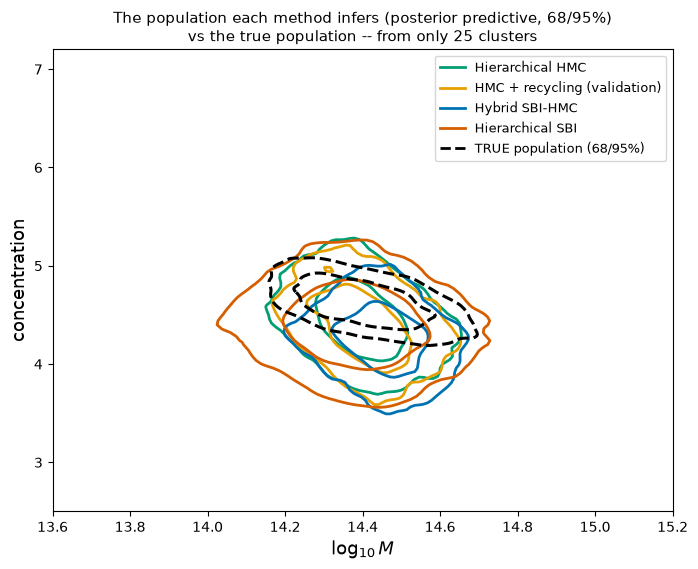

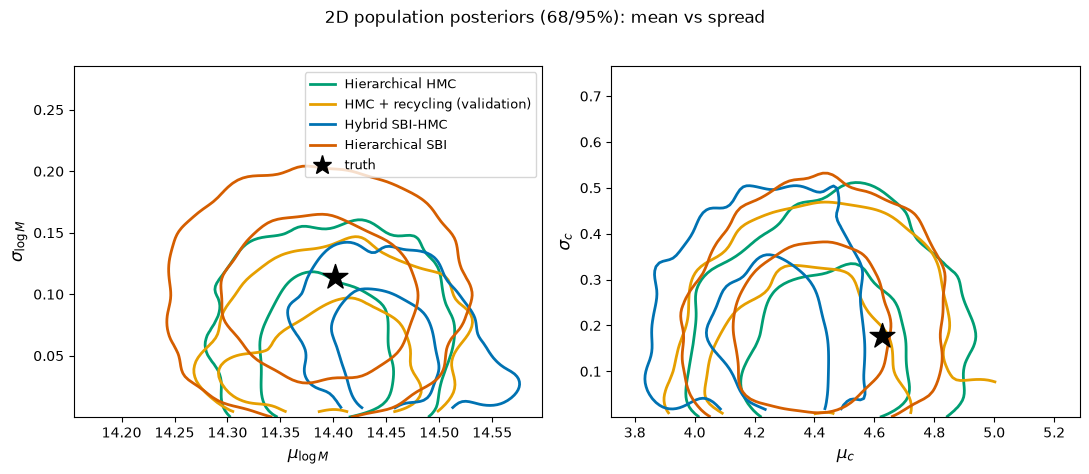

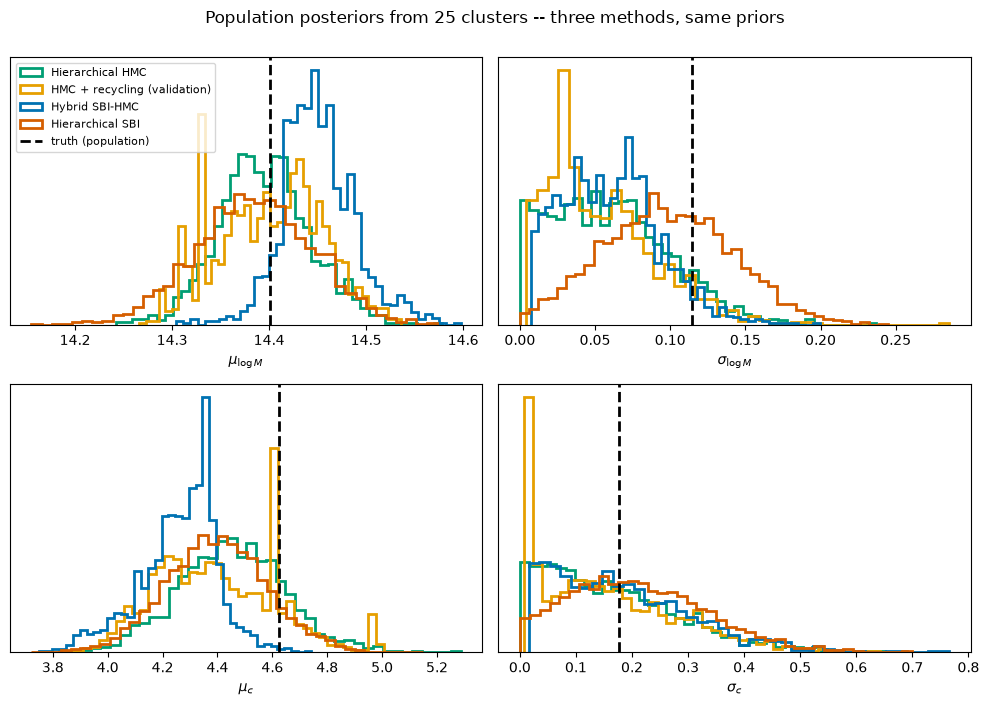

Timings (this run):
  observations_N25       cached
  truth_population       cached
  percluster_npe         cached
  percluster_samples_N25 cached
  green_hmc_N25          cached
  brown_recycled_N25     cached
  percluster_hmc_S12k_N25 cached
  teal_recycled_S12k_N25 cached
  population_npe_N25     cached
  purple_samples_N25     cached


In [9]:
METHODS = [("Hierarchical HMC", GREEN, "#009E73"),
           ("HMC + recycling (validation)", TEAL, "#E69F00"),
           ("Hybrid SBI-HMC", BROWN, "#0072B2"),
           ("Hierarchical SBI", PURPLE, "#D55E00")]
PARAMS  = [("mu_M", r"$\mu_{\log M}$"), ("sig_M", r"$\sigma_{\log M}$"),
           ("mu_c", r"$\mu_c$"), ("sig_c", r"$\sigma_c$")]

# THE key comparison: each method's inferred POPULATION in the (logM, c) plane.
# Draw from the posterior predictive: sample hyperparameters from each method's posterior,
# then draw (logM, c) from the implied population Gaussian -- the mixture is "the population
# this method believes in", directly comparable to the true population.
def predictive_population(s, k=20000):
    rng = np.random.default_rng(0)
    idx = rng.integers(0, len(s["mu_M"]), k)
    logM = rng.normal(s["mu_M"][idx], s["sig_M"][idx])
    c    = rng.normal(s["mu_c"][idx], np.abs(s["sig_c"][idx]))
    return np.column_stack([logM, c])

fig, ax = plt.subplots(figsize=(8, 6))
for name, smp, color in METHODS:
    kde_contours(ax, predictive_population(smp), color, fill=False, lw=2.0)
kde_contours(ax, POP[:8000], "k", ls="--", lw=2.2)
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], color=c, lw=2, label=n) for n, _, c in METHODS]
          + [Line2D([], [], color="k", ls="--", lw=2, label="TRUE population (68/95%)")],
          fontsize=9, loc="upper right")
ax.set_xlabel(r"$\log_{10} M$", fontsize=13); ax.set_ylabel("concentration", fontsize=13)
ax.set_xlim(13.6, 15.2); ax.set_ylim(2.5, 7.2)
ax.set_title(f"The population each method infers (posterior predictive, 68/95%)\n"
             f"vs the true population -- from only {N_CLUSTERS} clusters", fontsize=11)
plt.show()

# 2D posteriors: the (mean, spread) planes for mass and concentration
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (kx, ky, lx, ly) in zip(axes, [("mu_M", "sig_M", r"$\mu_{\log M}$", r"$\sigma_{\log M}$"),
                                        ("mu_c", "sig_c", r"$\mu_c$", r"$\sigma_c$")]):
    for name, smp, color in METHODS:
        kde_contours(ax, np.column_stack([smp[kx], smp[ky]]), color, fill=False, lw=2.0)
    ax.scatter(TRUE[kx], TRUE[ky], marker="*", s=350, color="k", zorder=6, label="truth")
    ax.set_xlabel(lx, fontsize=12); ax.set_ylabel(ly, fontsize=12)
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([], [], color=c, lw=2, label=n) for n, _, c in METHODS]
               + [Line2D([], [], marker="*", ls="", ms=14, mfc="k", mec="k", label="truth")], fontsize=9)
fig.suptitle("2D population posteriors (68/95%): mean vs spread", y=1.02)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, (key, label) in zip(axes.ravel(), PARAMS):
    for name, s, color in METHODS:
        ax.hist(s[key], bins=40, density=True, histtype="step", lw=2, color=color, label=name)
    ax.axvline(TRUE[key], color="k", ls="--", lw=2, label="truth (population)")
    ax.set_xlabel(label); ax.set_yticks([])
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Population posteriors from {N_CLUSTERS} clusters -- three methods, same priors", y=1.0)
plt.tight_layout(); plt.show()

print("Timings (this run):")
for k, (status, dt) in TIMINGS.items():
    print(f"  {k:<22} {status}" + (f"  {dt:6.1f}s" if dt else ""))

## 5. What you just saw (and how it maps to the paper)

- **The three methods agree** (within sampling noise) — that is the paper's central check: the
  joint hierarchical likelihood (🟢), the cached-posterior recycling shortcut (🟤), and the
  end-to-end neural posterior (🟣) are three routes to the *same* population posterior.
- **With a small sample the posteriors are wide** — honestly so. The paper's analyses use
  $N_c = 376$ per bin (and thousands across bins), where $\sigma_M, \sigma_c$ tighten dramatically.
  Change `N_CLUSTERS` at the top and re-run (delete `cache/`) to watch that happen.
- **Why the hybrid matters:** the per-cluster NPE posteriors were computed *once* and cached
  (`data/percluster_posteriors.npz`). Re-fitting a *different* population model reuses them for
  free — no per-cluster inference is ever repeated. That is the workflow that scales.
- **Next tutorials:** importance-sampling details (undoing non-flat priors), out-of-distribution
  robustness, and the full richness–redshift-binned analysis.